<a href="https://colab.research.google.com/github/RamaB47/Projet-Isigny-Ste-Mere/blob/main/matrice_Isigny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Import of libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [6]:
dataset ="fichier_global_finalisé.csv"
df = pd.read_csv(dataset, sep=";")

In [7]:
colonne = ["RR","NBRR","TX","TN", "TM"]

In [8]:
df.head()

,",AAAAMM,RR,NBRR,TX,TN,TM,Unnamed: 0,Qté 1000L,cle_isigny,Prod_Isigny_Estimee"
0,"0,195802,64.2,18.0,,,,,,,"
1,"1,195803,55.9,31.0,,,,,,,"
2,"2,195804,25.9,30.0,,,,,,,"
3,"3,195805,52.2,31.0,,,,,,,"
4,"4,195806,100.9,30.0,,,,,,,"


In [9]:
list(df.columns)

[',AAAAMM,RR,NBRR,TX,TN,TM,Unnamed: 0,Qté 1000L,cle_isigny,Prod_Isigny_Estimee']

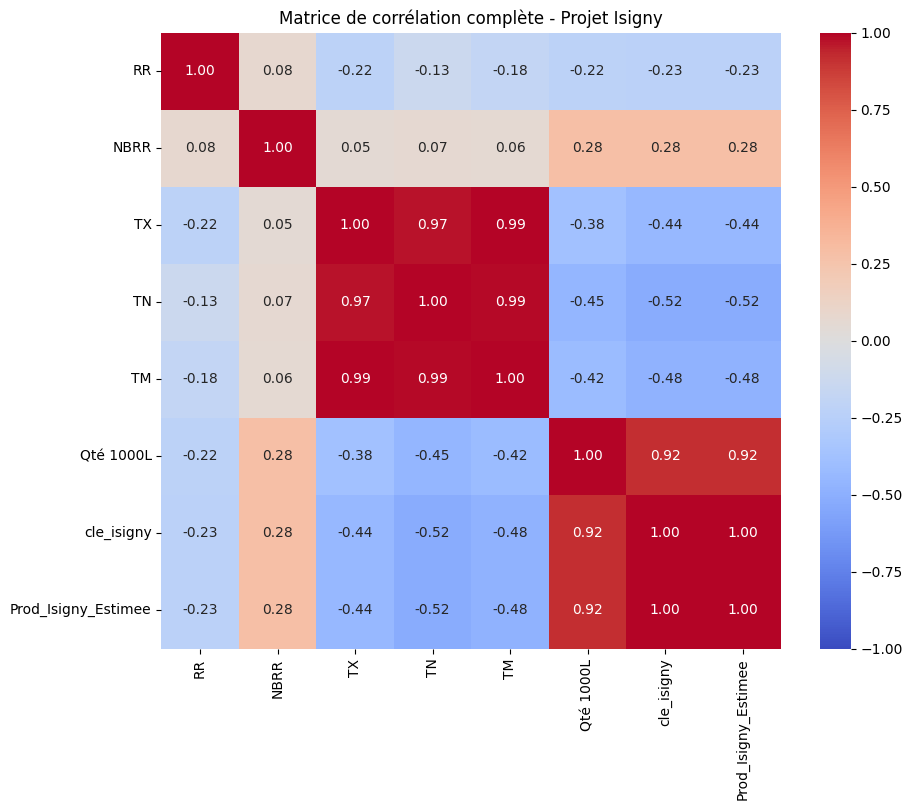

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. On récupère la colonne unique et on la découpe au niveau de chaque virgule
nom_colonne_unique = df.columns[0]
df_propre = df[nom_colonne_unique].str.split(",", expand=True)

# 2. On redonne les bons noms à nos nouvelles colonnes bien séparées
df_propre.columns = [
    "Index_Var",
    "AAAAMM",
    "RR",
    "NBRR",
    "TX",
    "TN",
    "TM",
    "Unnamed_0",
    "Qté 1000L",
    "cle_isigny",
    "Prod_Isigny_Estimee",
]

# 3. On convertit TOUTES les colonnes de chiffres en vrais nombres
colonnes_chiffres = [
    "RR",
    "NBRR",
    "TX",
    "TN",
    "TM",
    "Qté 1000L",
    "cle_isigny",
    "Prod_Isigny_Estimee",
]
for col in colonnes_chiffres:
    df_propre[col] = pd.to_numeric(df_propre[col], errors="coerce")

# 4. On écrase votre ancien df par ce tableau tout propre
df = df_propre

# 5. On extrait les colonnes numériques et on affiche ENFIN la matrice complète !
df_numerique = df.select_dtypes(include=["number"])
matrice_corr = df_numerique.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)

plt.title("Matrice de corrélation complète - Projet Isigny")
plt.show()

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Nettoyage des données (on s'assure d'éliminer les lignes vides sur ces colonnes)
df_simple = df[["TM", "Prod_Isigny_Estimee"]].dropna()

# 2. Définition des variables (X doit être un DataFrame/2D, y une série/1D)
X_simple = df_simple[["TM"]]
y_simple = df_simple["Prod_Isigny_Estimee"]

# 3. Entraînement du modèle
modele_simple = LinearRegression()
modele_simple.fit(X_simple, y_simple)

# 4. Extraction des indicateurs pour votre présentation
r2_simple = modele_simple.score(X_simple, y_simple)
pente = modele_simple.coef_[0]
ordonnee_origine = modele_simple.intercept_

print("--- RÉSULTATS RÉGRESSION SIMPLE ---")
print(f"Coefficient de détermination (R²) : {r2_simple:.4f}")
print(f"Impact d'un degré supplémentaire (Pente A) : {pente:.2f}")
print(f"Ligne de base (Constante B) : {ordonnee_origine:.2f}")

--- RÉSULTATS RÉGRESSION SIMPLE ---
Coefficient de détermination (R²) : 0.2278
Impact d'un degré supplémentaire (Pente A) : -176832.45
Ligne de base (Constante B) : 24902468.74


In [12]:
import pandas as pd
from prophet import Prophet

# 1. On crée le conteneur
df_prophet = pd.DataFrame()

# 2. On nettoie proprement la chaîne de caractères brute
# On enlève les espaces, les ".0" et on force le format YYYYMM-01
df_dates_brutes = (
    df["AAAAMM"].astype(str).str.split(".").str[0].str.strip().str.slice(stop=6)
)
dates_formatees = df_dates_brutes + "-01"

# 3. On convertit en spécifiant le format EXACT contenant le tiret (%Y%m-%d)
df_prophet["ds"] = pd.to_datetime(dates_formatees, format="%Y%m-%d")

# 4. On récupère le reste des données
df_prophet["y"] = pd.to_numeric(df["Prod_Isigny_Estimee"], errors="coerce")
df_prophet["TM"] = pd.to_numeric(df["TM"], errors="coerce")

# On nettoie les lignes vides
df_prophet = df_prophet.dropna()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


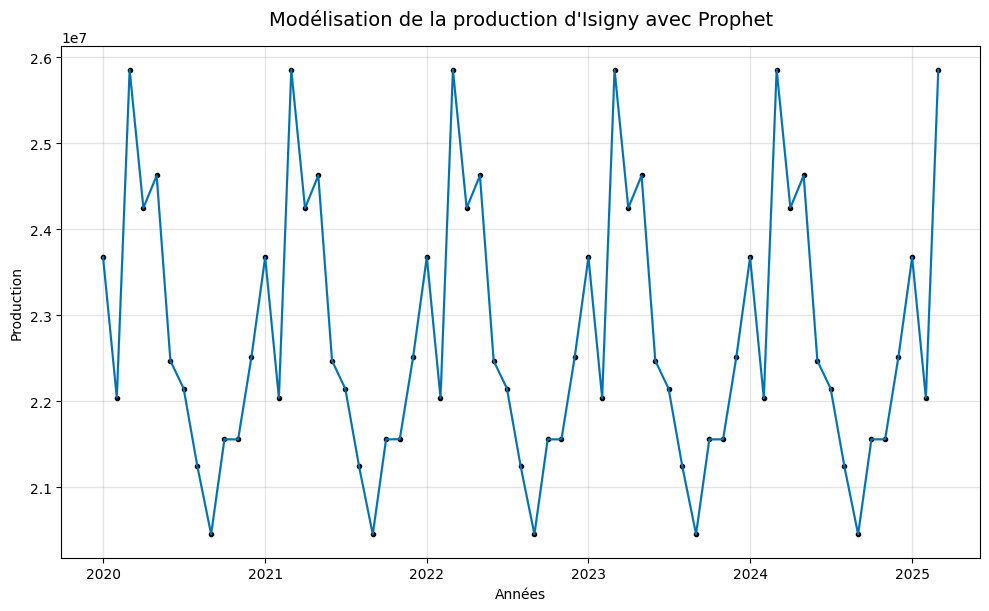

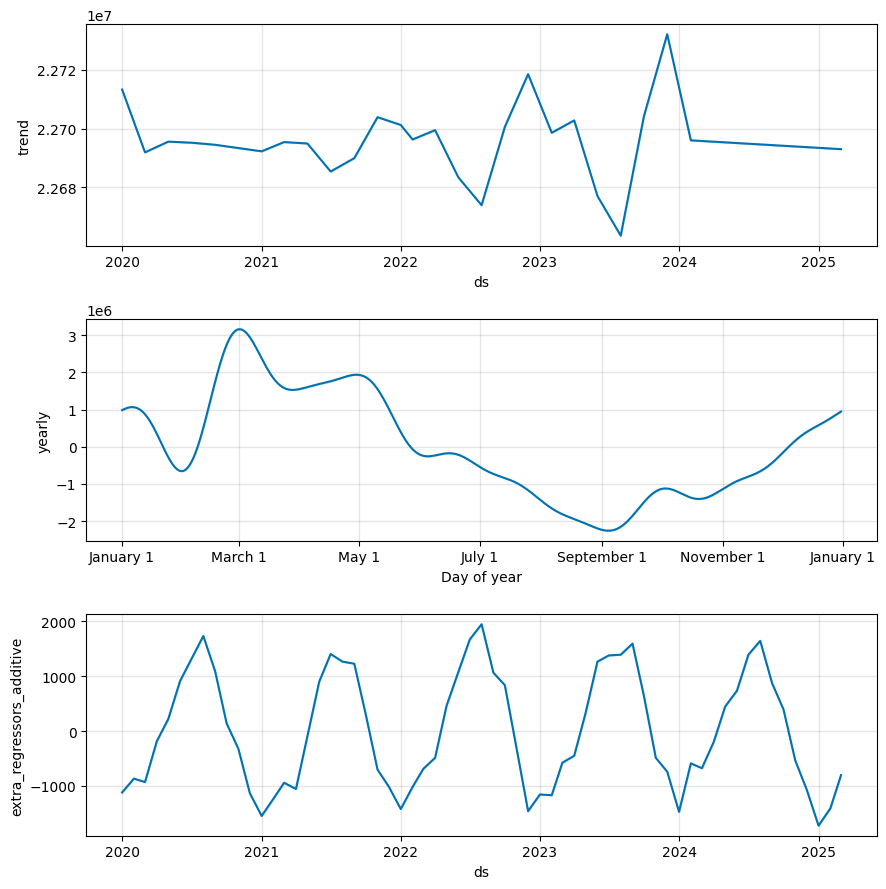

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet

# ==============================================================================
# 1. PRÉPARATION DU DATAFRAME AU FORMAT STRICT PROPHET
# ==============================================================================
df_prophet = pd.DataFrame()

# Nettoyage rigoureux de la colonne temporelle pour éviter l'erreur de parsing
df_dates_brutes = (
    df["AAAAMM"].astype(str).str.split(".").str[0].str.strip().str.slice(stop=6)
)
dates_formatees = df_dates_brutes + "-01"

# Conversion finale avec le format exact (%Y%m-%d)
df_prophet["ds"] = pd.to_datetime(dates_formatees, format="%Y%m-%d")

# Récupération des données numériques (les cibles et régresseurs)
df_prophet["y"] = pd.to_numeric(df["Prod_Isigny_Estimee"], errors="coerce")
df_prophet["TM"] = pd.to_numeric(df["TM"], errors="coerce")

# Suppression des lignes vides
df_prophet = df_prophet.dropna()

# ==============================================================================
# 2. CONFIGURATION ET ENTRAÎNEMENT DU MODÈLE
# ==============================================================================
# On active la saisonnalité annuelle (indispensable pour les cycles du lait)
modele_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)

# On ajoute l'impact de la température comme variable externe
modele_prophet.add_regressor("TM")

# Entraînement du modèle
modele_prophet.fit(df_prophet)

# ==============================================================================
# 3. PRÉDICTIONS ET SÉPARATION DES COMPOSANTES
# ==============================================================================
# Calcul des prédictions sur l'historique
predictions = modele_prophet.predict(df_prophet)

# Graphique 1 : Courbe globale des prédictions (Points noirs = Réel, Ligne bleue = Modèle)
fig1 = modele_prophet.plot(predictions)
plt.title(
    "Modélisation de la production d'Isigny avec Prophet",
    fontsize=14,
    pad=15,
)
plt.xlabel("Années")
plt.ylabel("Production")
plt.show()

# Graphique 2 : Décomposition (Tendance de fond VS Saisonnalité annuelle VS Impact de la météo)
fig2 = modele_prophet.plot_components(predictions)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


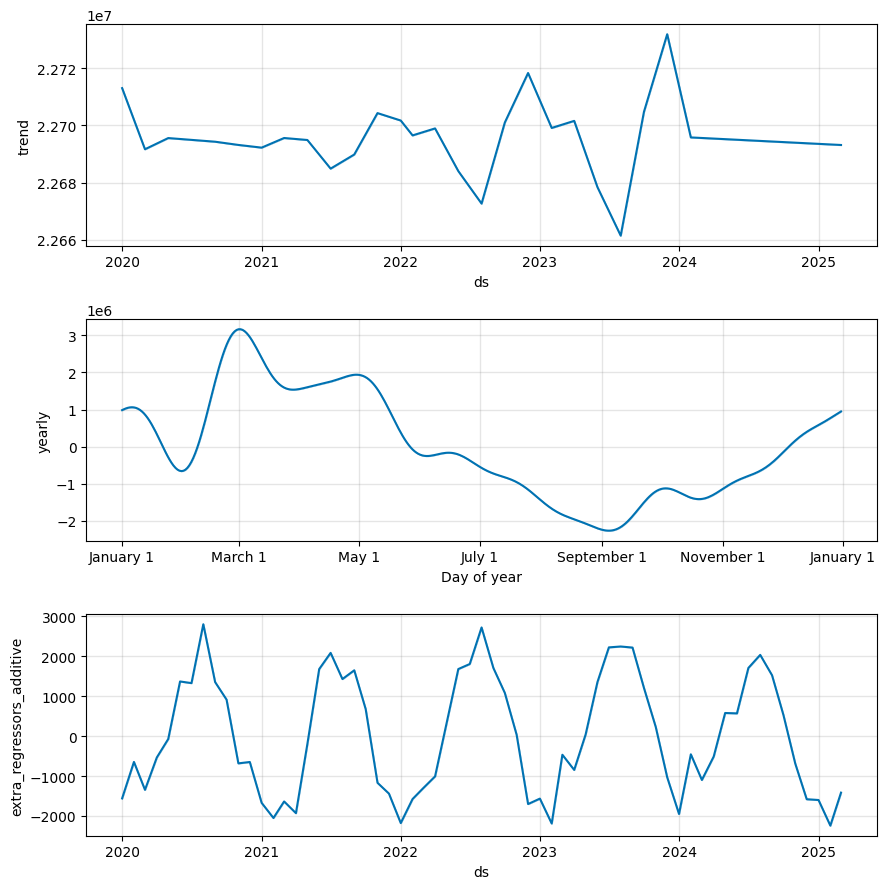

In [14]:
# ==============================================================================
# 1. PRÉPARATION DU DATAFRAME AVEC LA PLUVIOMÉTRIE (RR)
# ==============================================================================
df_prophet = pd.DataFrame()

df_dates_brutes = (
    df["AAAAMM"].astype(str).str.split(".").str[0].str.strip().str.slice(stop=6)
)
dates_formatees = df_dates_brutes + "-01"
df_prophet["ds"] = pd.to_datetime(dates_formatees, format="%Y%m-%d")

# On récupère la cible et NOS DEUX variables climatiques
df_prophet["y"] = pd.to_numeric(df["Prod_Isigny_Estimee"], errors="coerce")
df_prophet["TM"] = pd.to_numeric(df["TM"], errors="coerce")
df_prophet["RR"] = pd.to_numeric(
    df["RR"], errors="coerce"
)  # <-- Ajout de la pluie

df_prophet = df_prophet.dropna()

# ==============================================================================
# 2. CONFIGURATION ET MULTI-RÉGRESSEURS
# ==============================================================================
modele_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)

# On déclare les deux variables à Prophet
modele_prophet.add_regressor("TM")
modele_prophet.add_regressor("RR")  # <-- On dit à Prophet de tester la pluie

modele_prophet.fit(df_prophet)

# ==============================================================================
# 3. PRÉDICTIONS ET SÉPARATION DES COMPOSANTES
# ==============================================================================
predictions = modele_prophet.predict(df_prophet)

# Affichage des composants (Tendance, Saisonnalité, Effet TM, Effet RR)
fig2 = modele_prophet.plot_components(predictions)
plt.show()

In [21]:
import pandas as pd

# 1. On charge le vrai DataFrame à partir du chemin de fichier contenu dans dataset
df_origine_propre = pd.read_csv(dataset) # ou pd.read_excel(dataset) si c'est un Excel

# 2. Si votre colonne de date s'appelle 'AAAAMM', on la renomme en 'ds'
if 'AAAAMM' in df_origine_propre.columns:
    df_origine_propre = df_origine_propre.rename(columns={'AAAAMM': 'ds'})

# 3. On harmonise les formats de date pour éviter les conflits
df_prophet['ds'] = df_prophet['ds'].astype(str)
df_origine_propre['ds'] = df_origine_propre['ds'].astype(str)

# 4. Fusion finale
df_powerbi = pd.merge(df_prophet, df_origine_propre, on='ds', how='left')

print(df_powerbi.head())

           ds          yhat    yhat_lower    yhat_upper         trend  \
0  2020-01-01  2.367546e+07  2.367403e+07  2.367695e+07  2.271304e+07   
1  2020-02-01  2.204447e+07  2.204323e+07  2.204585e+07  2.270199e+07   
2  2020-03-01  2.585550e+07  2.585416e+07  2.585689e+07  2.269166e+07   
3  2020-04-01  2.425083e+07  2.424944e+07  2.425219e+07  2.269365e+07   
4  2020-05-01  2.462734e+07  2.462585e+07  2.462875e+07  2.269557e+07   

         yearly  Unnamed: 0.1  RR  NBRR  TX  TN  TM  Unnamed: 0  Qté 1000L  \
0  9.639852e+05           NaN NaN   NaN NaN NaN NaN         NaN        NaN   
1 -6.568775e+05           NaN NaN   NaN NaN NaN NaN         NaN        NaN   
2  3.165191e+06           NaN NaN   NaN NaN NaN NaN         NaN        NaN   
3  1.557718e+06           NaN NaN   NaN NaN NaN NaN         NaN        NaN   
4  1.931846e+06           NaN NaN   NaN NaN NaN NaN         NaN        NaN   

   cle_isigny  Prod_Isigny_Estimee  
0         NaN                  NaN  
1         NaN     

/tmp/ipykernel_2254/2472586134.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prophet['ds'] = df_prophet['ds'].astype(str)


In [24]:
df_powerbi.to_csv("fichier_prédictif_Isigny.csv")